# Credit Card Fraud Detection - Midpoint Baseline Model
This notebook contains the exploratory data analysis (EDA), data preprocessing, and baseline Logistic Regression model for our credit card fraud detection project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, precision_recall_curve, auc

# Set plot style for better-looking visuals
sns.set_theme(style="whitegrid")

Loading dataset...
Calculating class distribution...
Legitimate Transactions: 284315
Fraudulent Transactions: 492
Percentage of Fraud: 0.173%



/var/folders/51/kkgylr0s7vd8971v07bhrc040000gn/T/ipykernel_17455/644584928.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='pastel')


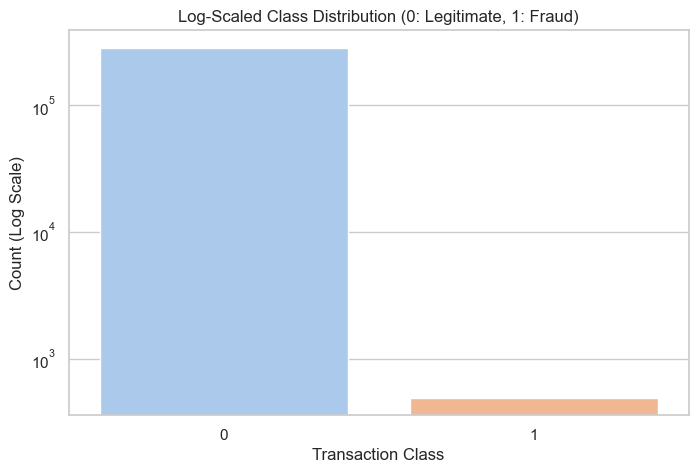

In [2]:
# 1. Data Loading
print("Loading dataset...")
df = pd.read_csv('creditcard.csv')

# 2. Exploratory Data Analysis (EDA) - Class Distribution
print("Calculating class distribution...")
class_counts = df['Class'].value_counts()
fraud_percentage = (class_counts[1] / len(df)) * 100
print(f"Legitimate Transactions: {class_counts[0]}")
print(f"Fraudulent Transactions: {class_counts[1]}")
print(f"Percentage of Fraud: {fraud_percentage:.3f}%\n")

# Generate a plot showing the massive imbalance
plt.figure(figsize=(8, 5))
sns.countplot(x='Class', data=df, palette='pastel')
plt.yscale('log') # Log scale is necessary because legitimate transactions dwarf fraud
plt.title('Log-Scaled Class Distribution (0: Legitimate, 1: Fraud)')
plt.xlabel('Transaction Class')
plt.ylabel('Count (Log Scale)')
plt.savefig('class_imbalance.png', bbox_inches='tight')
plt.show()

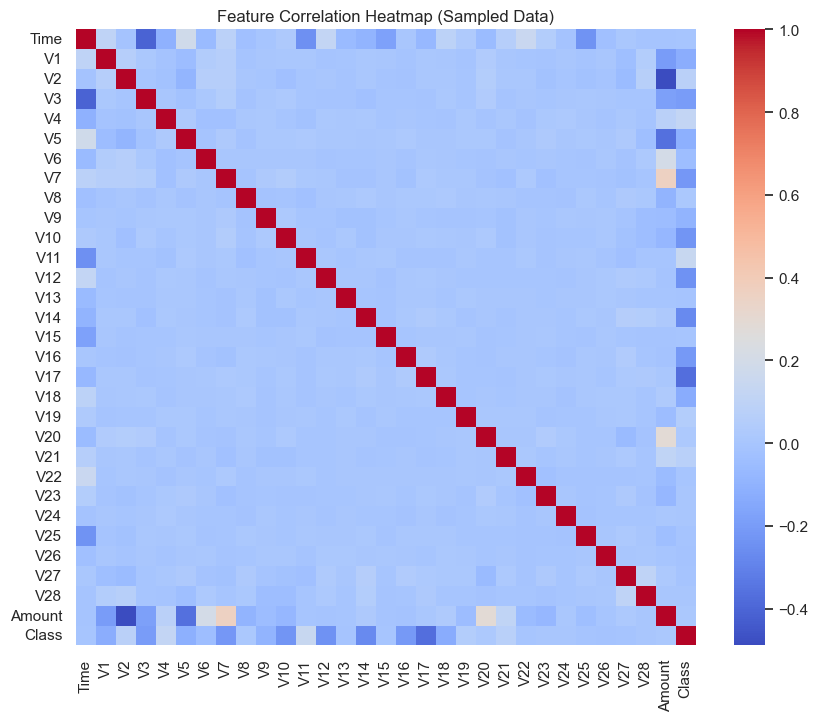

/var/folders/51/kkgylr0s7vd8971v07bhrc040000gn/T/ipykernel_17455/3199784478.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Amount', data=df, palette='Set2')


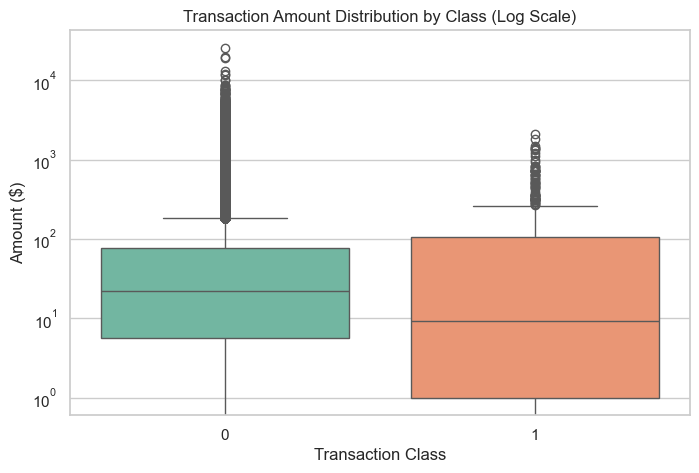

In [3]:
# --- NEW ADDITIONS FOR SPRUCED UP DIAGRAMS ---

# 1. Correlation Heatmap
# This shows if any of the V1-V28 features are highly correlated with each other or the target Class.
# We sample 20,000 rows to make it render faster without losing the overall pattern.
plt.figure(figsize=(10, 8))
sns.heatmap(df.sample(20000, random_state=42).corr(), cmap='coolwarm', cbar=True)
plt.title('Feature Correlation Heatmap (Sampled Data)')
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

# 2. Transaction Amount vs. Class
# This helps us visually inspect if fraudsters make larger or smaller purchases on average.
plt.figure(figsize=(8, 5))
sns.boxplot(x='Class', y='Amount', data=df, palette='Set2')
plt.yscale('log') # Log scale because transaction amounts vary wildly
plt.title('Transaction Amount Distribution by Class (Log Scale)')
plt.xlabel('Transaction Class')
plt.ylabel('Amount ($)')
plt.savefig('amount_distribution.png', bbox_inches='tight')
plt.show()

In [4]:
# 3. Preprocessing
print("Preprocessing data...")

# Separate features (X) from the target label (y)
X = df.drop('Class', axis=1)
y = df['Class']

# Stratified split is CRITICAL here. 
# It ensures the 0.17% fraud cases are distributed evenly (80/20) between the training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# The V1-V28 features are already PCA transformed (scaled), but Time and Amount are not.
# We must scale them so the Logistic Regression doesn't weigh "Amount" heavier just because the numbers are bigger.
scaler = StandardScaler()

# Fit the scaler ONLY on training data to prevent data leakage, then transform both train and test sets.
X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])
print("Data scaling and splitting complete.")

Preprocessing data...
Data scaling and splitting complete.


In [5]:
# 4. Baseline Modeling (Logistic Regression)
print("\nTraining Baseline Logistic Regression Model...")

# We use Logistic Regression as our baseline because it is fast, interpretable, and standard.
# max_iter is increased to 1000 to ensure the optimization algorithm converges properly.
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train, y_train)

# Generate predictions and probabilities for the test set
y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1] # Index 1 grabs the probability of it being Class 1 (Fraud)
print("Model training complete.")


Training Baseline Logistic Regression Model...
Model training complete.


Evaluating Baseline Model...

--- Baseline Results ---
Precision: 0.8289
Recall:    0.6429
F1-Score:  0.7241
PR-AUC:    0.7420

Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



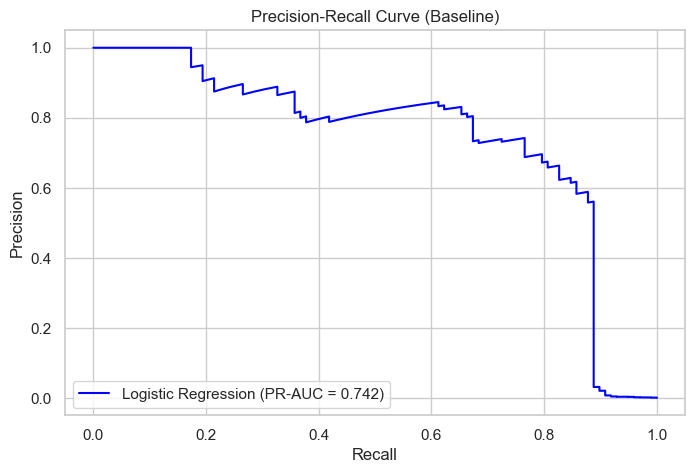

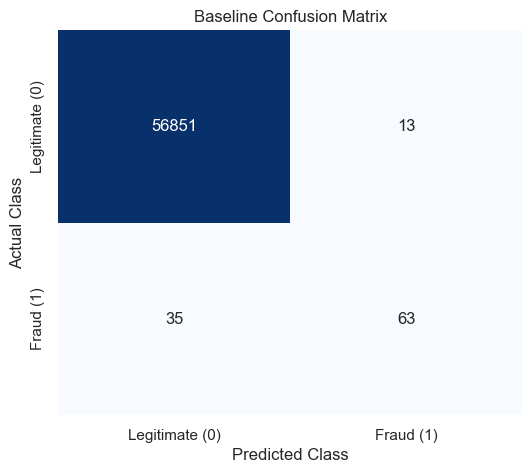

/var/folders/51/kkgylr0s7vd8971v07bhrc040000gn/T/ipykernel_17455/2822321125.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=feat_imp_df.head(10), palette='coolwarm')


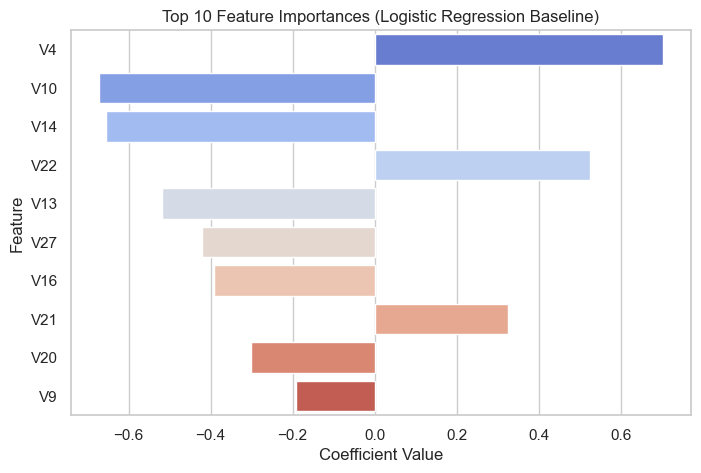

In [6]:
# 5. Evaluation
print("Evaluating Baseline Model...\n")

# Calculate core metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Calculate Precision-Recall Area Under Curve (PR-AUC)
# This is our primary metric for imbalanced data, as stated in the project proposal.
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall_curve, precision_curve)

print("--- Baseline Results ---")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"PR-AUC:    {pr_auc:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

# Visual 1: PR-Curve
plt.figure(figsize=(8, 5))
plt.plot(recall_curve, precision_curve, label=f'Logistic Regression (PR-AUC = {pr_auc:.3f})', color='blue')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Baseline)')
plt.legend(loc='lower left')
plt.grid(True)
plt.savefig('pr_curve_baseline.png', bbox_inches='tight')
plt.show()

# Visual 2: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Legitimate (0)', 'Fraud (1)'],
            yticklabels=['Legitimate (0)', 'Fraud (1)'])
plt.title('Baseline Confusion Matrix')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.savefig('confusion_matrix_baseline.png', bbox_inches='tight')
plt.show()

# Visual 3: Feature Importance
# Extracts the coefficients to see which features the baseline model relies on most.
importance = baseline_model.coef_[0]
feature_names = X_train.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': importance})
feat_imp_df['Abs_Coefficient'] = feat_imp_df['Coefficient'].abs()
feat_imp_df = feat_imp_df.sort_values(by='Abs_Coefficient', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=feat_imp_df.head(10), palette='coolwarm')
plt.title('Top 10 Feature Importances (Logistic Regression Baseline)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

In [7]:
import numpy as np
# Get the probabilities from your baseline model
baseline_probs = baseline_model.predict_proba(X_test)[:, 1]

# Save them to a file
np.savez('baseline_predictions.npz', baseline_lr=baseline_probs)
print("Baseline predictions saved!")

Baseline predictions saved!
